1) Perform filtering and normalisation: Explain the reason for chosen your threshold for filtering with appropriate figures and rational for normalisation?

## Reproducibility note

Raw `.h5ad` input files are excluded from Git because they are large single-cell data files. To run this notebook, place the expected sample folders under `data/raw/cscc/` or set the `CSCC_DATA_ROOT` environment variable to the directory containing the sample folders. Full reproducibility still requires access to the original data source and documented download instructions.


In [1]:
from pathlib import Path
import os
import importlib.util

import scanpy as sc
import scanpy.external as sce
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = Path(os.environ.get("CSCC_DATA_ROOT", PROJECT_ROOT / "data" / "raw" / "cscc")).expanduser()
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_NAMES = [
    "P2_normal",
    "P2_cSCC",
    "P3_normal",
    "P3_cSCC1",
    "P3_cSCC2",
    "P4_normal",
    "P4_cSCC1",
    "P4_cSCC2",
    "P5_normal",
    "P5_cSCC",
]

sample_paths = {
    sample_name: DATA_ROOT / sample_name / "filtered_feature_bc_matrix.h5ad"
    for sample_name in SAMPLE_NAMES
}

missing_files = [path for path in sample_paths.values() if not path.exists()]
if missing_files:
    missing_text = "\n".join(f"- {path}" for path in missing_files)
    raise FileNotFoundError(
        "Missing cSCC input files. Expected each sample folder to contain "
        "filtered_feature_bc_matrix.h5ad.\n\n"
        f"DATA_ROOT currently resolves to: {DATA_ROOT}\n\n"
        "Set CSCC_DATA_ROOT to the directory containing the sample folders, for example:\n"
        "export CSCC_DATA_ROOT=/path/to/local/cscc_data\n\n"
        f"Missing files:\n{missing_text}"
    )

samples = {
    sample_name: sc.read_h5ad(path)
    for sample_name, path in sample_paths.items()
}


In [2]:
for sample_name, adata_i in samples.items():
    adata_i.obs_names = [f"{sample_name}_{barcode}" for barcode in adata_i.obs_names]
    adata_i.obs_names_make_unique()
    adata_i.var_names_make_unique()
    adata_i.obs["patient"] = sample_name.split("_")[0]
    adata_i.obs["condition"] = "normal" if "normal" in sample_name else "cSCC"
    adata_i.obs["source_sample"] = sample_name

p3_t = sc.concat(
    [samples["P3_cSCC1"], samples["P3_cSCC2"]],
    join="outer",
    label="source_sample_part",
    keys=["P3_cSCC1", "P3_cSCC2"],
)
p3_t.obs["patient"] = "P3"
p3_t.obs["condition"] = "cSCC"
p3_t.obs["source_sample"] = "P3_cSCC"

p4_t = sc.concat(
    [samples["P4_cSCC1"], samples["P4_cSCC2"]],
    join="outer",
    label="source_sample_part",
    keys=["P4_cSCC1", "P4_cSCC2"],
)
p4_t.obs["patient"] = "P4"
p4_t.obs["condition"] = "cSCC"
p4_t.obs["source_sample"] = "P4_cSCC"

adata = sc.concat(
    [
        samples["P2_normal"],
        samples["P2_cSCC"],
        samples["P3_normal"],
        p3_t,
        samples["P4_normal"],
        p4_t,
        samples["P5_normal"],
        samples["P5_cSCC"],
    ],
    join="outer",
    label="sample",
    keys=["P2_normal", "P2_cSCC", "P3_normal", "P3_cSCC", "P4_normal", "P4_cSCC", "P5_normal", "P5_cSCC"],
)

adata


AnnData object with n_obs × n_vars = 31456 × 36601
    obs: 'patient', 'condition', 'source_sample', 'source_sample_part', 'sample'

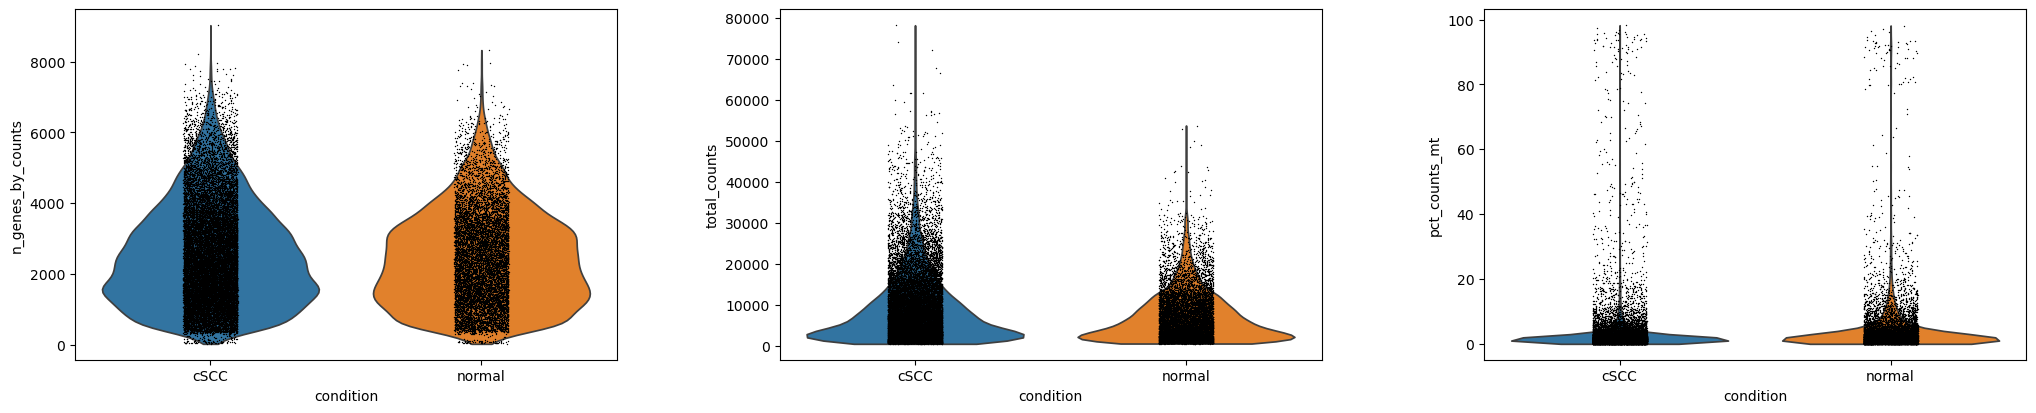

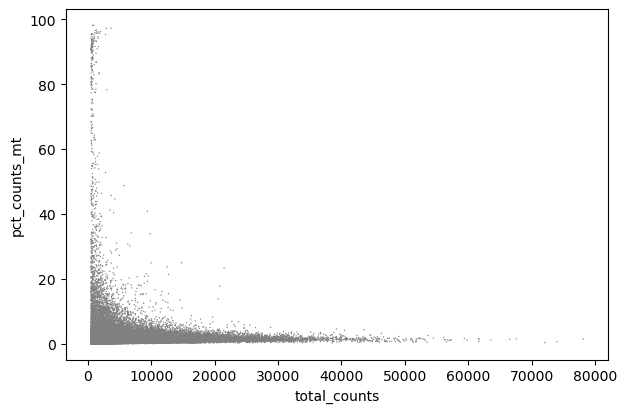

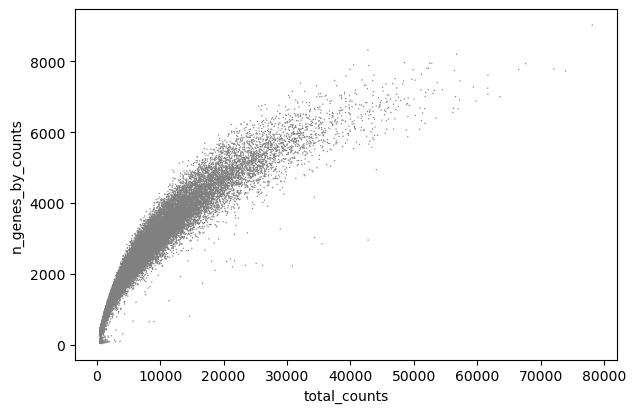

In [3]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="condition",
    multi_panel=True,
    show=False,
)
plt.gcf().savefig(FIGURE_DIR / "01_qc_metrics_by_condition.png", dpi=300, bbox_inches="tight")
plt.show()

sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")


In [4]:
adata = adata[
    (adata.obs["n_genes_by_counts"] > 500) &
    (adata.obs["n_genes_by_counts"] < 6000) &
    (adata.obs["pct_counts_mt"] < 10) &
    (adata.obs["total_counts"] > 1000) &
    (adata.obs["total_counts"] < 50000)
].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
adata = adata[:, adata.var["highly_variable"]].copy()

adata


AnnData object with n_obs × n_vars = 27995 × 2000
    obs: 'patient', 'condition', 'source_sample', 'source_sample_part', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'condition_colors', 'log1p', 'hvg'

Cells were filtered based on the QC metric distributions. Cells with fewer than 500 detected genes were excluded as likely low-quality cells, while those with more than 6,000 genes were removed to reduce potential doublets. 
A mitochondrial content threshold of 10% was applied to exclude stressed or dying cells, as indicated by the high-value tail in the distribution. 
Cells with very low total counts (<1,000) were removed due to insufficient RNA content, and very high counts (>50,000) were excluded as they may represent doublets.
These thresholds were chosen to retain the main population of high-quality cells.

2) If you are using dimensionality reduction and integration methods in your pipeline, explain why and how it will affect your downstream anakysis?

In [5]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)

neighbor_rep = "X_pca"

if importlib.util.find_spec("harmonypy") is not None:
    try:
        sce.pp.harmony_integrate(adata, key="patient")
        has_harmony = "X_pca_harmony" in adata.obsm
        valid_harmony = has_harmony and adata.obsm["X_pca_harmony"].shape[0] == adata.n_obs

        if valid_harmony:
            neighbor_rep = "X_pca_harmony"
        else:
            harmony_shape = adata.obsm["X_pca_harmony"].shape if has_harmony else None
            print(
                "Harmony integration did not produce a valid X_pca_harmony matrix; "
                f"using X_pca instead. X_pca_harmony shape: {harmony_shape}; "
                f"expected first dimension: {adata.n_obs}."
            )
    except Exception as exc:
        print(f"Harmony integration failed; using X_pca instead. Details: {exc}")
else:
    print(
        "harmonypy is not installed in this environment; "
        "using unintegrated PCA coordinates for neighbors and UMAP. "
        "Install harmonypy to regenerate integrated results."
    )

sc.pp.neighbors(adata, use_rep=neighbor_rep)
sc.tl.umap(adata)


/opt/anaconda3/envs/cscc-scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


2026-06-07 01:41:47,310 - harmonypy - INFO - Running Harmony (PyTorch on mps)


2026-06-07 01:41:47,310 - harmonypy - INFO -   Parameters:


2026-06-07 01:41:47,310 - harmonypy - INFO -     max_iter_harmony: 10


2026-06-07 01:41:47,310 - harmonypy - INFO -     max_iter_kmeans: 20


...

2026-06-07 01:41:49,176 - harmonypy - INFO - Iteration 3 of 10


2026-06-07 01:41:49,749 - harmonypy - INFO - Iteration 4 of 10


2026-06-07 01:41:50,346 - harmonypy - INFO - Iteration 5 of 10


2026-06-07 01:41:50,883 - harmonypy - INFO - Converged after 5 iterations


Harmony integration failed; using X_pca instead. Details: Value passed for key 'X_pca_harmony' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (50,) while it should have had (27995,).


PCA was used to reduce the dimensionality of the gene expression data, mainly to capture the major sources of variation while getting rid of some of the noise. Working in this lower-dimensional space also makes later steps like building the neighbourhood graph and clustering more manageable. UMAP was then used to visualise the cells in two dimensions, which makes it easier to see how different cell populations are arranged and how they relate to each other.

Since the data comes from multiple patients, there is a possibility that cells could group by patient instead of their biological identity. To address this, Harmony was applied to correct for batch effects between patients. After integration, cells are more likely to group based on their gene expression profiles instead of where they came from. This is important for downstream analysis, especially clustering and cell type identification, because it reduces the chance of picking up patient-driven patterns rather than real biological differences. Overall, these steps help make the results more consistent and easier to interpret.

3) perform neighbourhood, clustering and UMAP analysis
   a) compare at least three different resolutions and which one you will choose and why?
   b) comment how these steps are affecting your Seurat / Anndata object
   hint : look at athe metadata / explore the Anndata object

/var/folders/cy/ggjmyh4x3_j0fn2cqsk1f_800000gn/T/ipykernel_49893/3813649095.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.2, key_added="leiden_0.2")


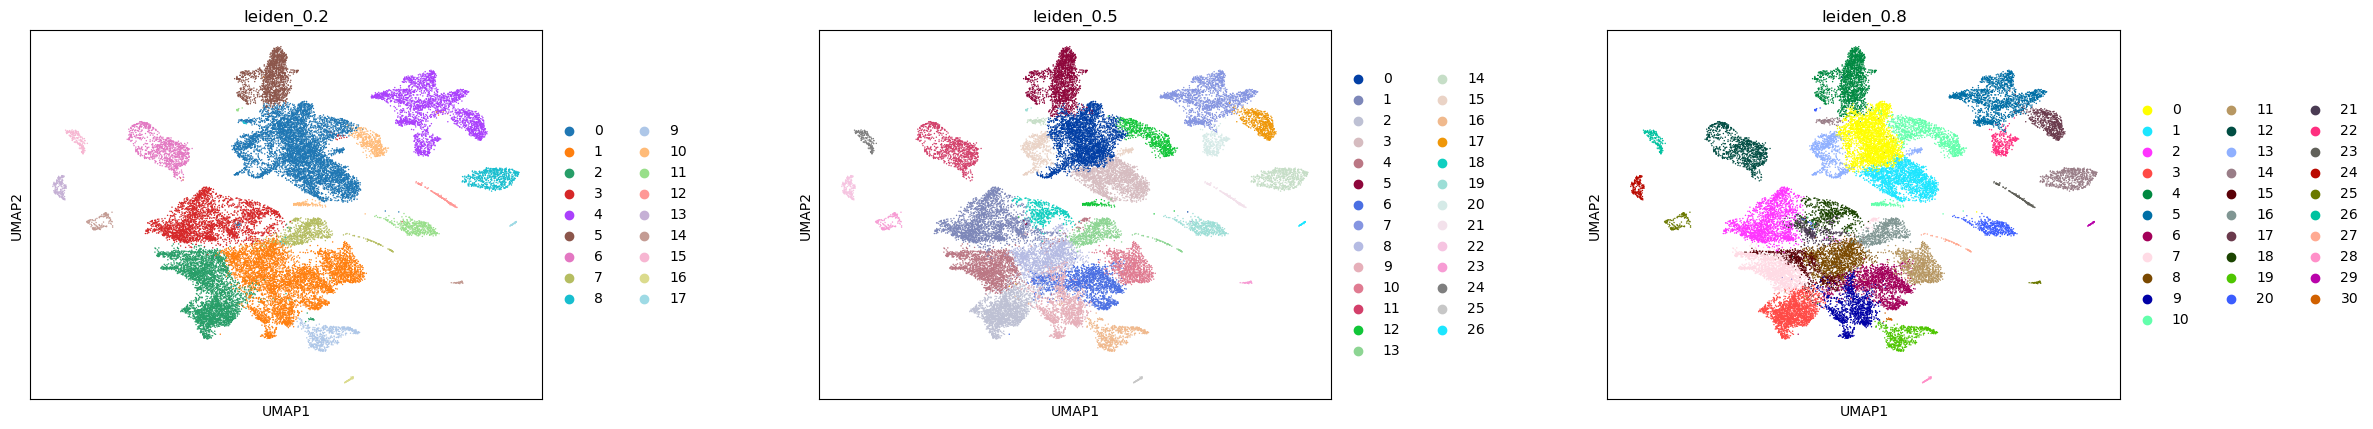

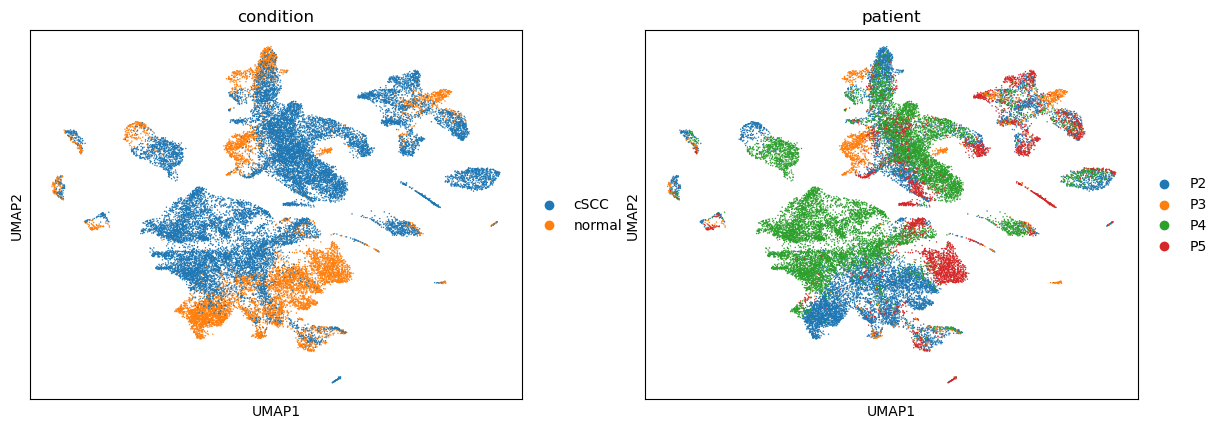

leiden_0.2
0     6521
1     5430
2     3889
3     2956
4     2633
5     1628
6      997
7      826
8      646
9      576
10     556
11     450
12     216
13     207
14     185
15     183
16      52
17      44
Name: count, dtype: int64
leiden_0.5
0     3462
1     2422
2     2001
3     1956
4     1888
5     1768
6     1745
7     1717
8     1440
9     1296
10    1032
11     997
12     815
13     747
14     718
15     648
16     597
17     590
18     485
19     450
20     334
21     216
22     207
23     185
24     183
25      52
26      44
Name: count, dtype: int64
leiden_0.8
0     3007
1     1954
2     1953
3     1891
4     1744
5     1709
6     1587
7     1567
8     1313
9     1203
10    1119
11    1034
12     999
13     794
14     732
15     728
16     706
17     601
18     599
19     571
20     462
21     421
22     334
23     216
24     207
25     185
26     183
27      64
28      52
29      44
30      16
Name: count, dtype: int64


In [6]:
neighbor_rep = "X_pca_harmony" if "X_pca_harmony" in adata.obsm else "X_pca"
sc.pp.neighbors(adata, use_rep=neighbor_rep)
sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=0.2, key_added="leiden_0.2")
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_0.5")
sc.tl.leiden(adata, resolution=0.8, key_added="leiden_0.8")

sc.pl.umap(adata, color=["leiden_0.2", "leiden_0.5", "leiden_0.8"], wspace=0.4)

fig = sc.pl.umap(adata, color=["condition", "patient"], return_fig=True, show=False)
fig.savefig(FIGURE_DIR / "02_umap_condition_patient.png", dpi=300, bbox_inches="tight")
plt.show()

print(adata.obs["leiden_0.2"].value_counts())
print(adata.obs["leiden_0.5"].value_counts())
print(adata.obs["leiden_0.8"].value_counts())


a) Leiden clustering was performed at resolutions 0.2, 0.5, and 0.8 to assess the effect of clustering granularity. At resolution 0.2, only a small number of broad cell populations were identified, suggesting under-clustering. At resolution 0.8, the data were partitioned into a larger number of clusters, some of which appeared overly fragmented, suggesting possible over-clustering. Resolution 0.5 was selected for downstream analysis because it provided a balance between identifying biologically distinct populations and avoiding excessive fragmentation.

In [7]:
print(adata.uns.keys())
print(adata.obsp.keys())
print(adata.obsm.keys())
print(adata.obsm["X_umap"][:5])
print(adata.obs.columns)
adata.obs.head()


odict_keys(['condition_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_0.2', 'leiden_0.5', 'leiden_0.8', 'leiden_0.2_colors', 'leiden_0.5_colors', 'leiden_0.8_colors', 'patient_colors'])
KeysView(PairwiseArrays with keys: distances, connectivities)
KeysView(AxisArrays with keys: X_pca, X_umap)
[[ 1.5539761e+01  3.2138209e+00]
 [-4.9308586e-01 -2.2118504e+00]
 [-3.4403963e+00 -5.1547232e+00]
 [-6.2391979e-01 -2.1673670e+00]
 [ 9.3523357e-03 -4.0753827e+00]]
Index(['patient', 'condition', 'source_sample', 'source_sample_part', 'sample',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_0.2', 'leiden_0.5',
       'leiden_0.8'],
      dtype='object')


,patient,condition,source_sample,source_sample_part,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,leiden_0.2,leiden_0.5,leiden_0.8
P2_normal_AAACCTGAGAAACCGC-1,P2,normal,P2_normal,NaN,P2_normal,1829,7.512071,5912.0,8.684909,57.746955,62.110961,67.760487,77.520298,249.0,5.521461,4.211772,17,26,29
P2_normal_AAACCTGAGACAAAGG-1,P2,normal,P2_normal,NaN,P2_normal,2791,7.934513,5522.0,8.616676,21.640710,28.812025,37.359652,52.191235,199.0,5.298317,3.603767,1,6,15
P2_normal_AAACCTGAGTGACATA-1,P2,normal,P2_normal,NaN,P2_normal,2277,7.731053,5685.0,8.645762,30.167106,40.281442,50.413369,64.626209,106.0,4.672829,1.864556,2,2,3
P2_normal_AAACCTGCAAACCCAT-1,P2,normal,P2_normal,NaN,P2_normal,4973,8.511980,16443.0,9.707716,25.451560,34.841574,44.322812,56.157635,417.0,6.035481,2.536034,1,6,15
P2_normal_AAACCTGCAAAGTCAA-1,P2,normal,P2_normal,NaN,P2_normal,4036,8.303257,11599.0,9.358761,24.390034,35.615139,45.374601,57.944650,63.0,4.158883,0.543150,1,9,9


b) The neighbourhood step computes a graph of transcriptionally similar cells and stores this in the AnnData object as a connectivity matrix and distance matrix. These are used as the basis for both clustering and UMAP.
UMAP adds a low-dimensional representation of the data to the AnnData object, stored in 'adata.obsm["X_umap"]', which is used for visualisation.
Leiden clustering adds cluster labels to the cell metadata 'adata.obs', allowing each cell to be assigned to a cluster at a given resolution. Different resolutions therefore create different metadata columns corresponding to different clustering granularities.

4) Read the data again and perform all your steps again excluding integration step and compare the UMAP with and without integration. If the UMAP looks different, explain briefly why?

### Deprecated duplicate workflow

This cell previously repeated data loading, preprocessing, integration, and UMAP comparison using hard-coded absolute paths. The reproducible workflow above now performs loading, preprocessing, optional Harmony integration, clustering, UMAP generation, and figure export from the configurable `DATA_ROOT`.


Compared with the integrated analysis, the UMAP without integration is expected to show stronger separation by patient, reflecting batch or sample-specific effects. In contrast, the integrated UMAP should show improved mixing of cells across patients, allowing clustering to reflect biological similarity rather than technical variation. Therefore, integration reduces patient-specific batch effects and changes the structure of the neighbour graph used for UMAP embedding.

5) perform differential expression gene analysis on ontegrated object and annotate as many cluster as you can. confirm your cluster annotation with the markers expression by using plots
   hint :  what normal cell types you can expect in skin? you are free to use manual annotation or any cell anntation tool(for example scType.)

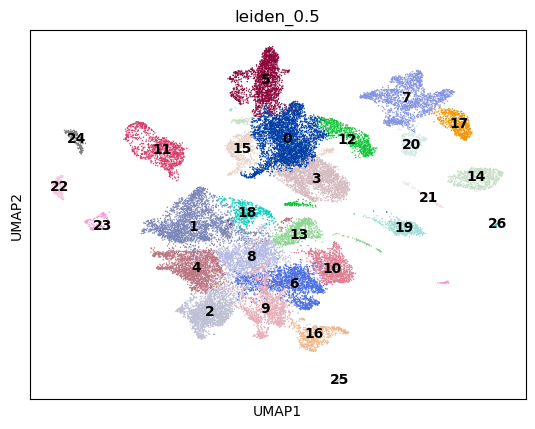


cluster: 0


/opt/anaconda3/envs/cscc-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/opt/anaconda3/envs/cscc-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/opt/anaconda3/envs/cscc-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning:

,names,scores,logfoldchanges,pvals,pvals_adj
2,LYZ,80.395180,5.388364,0.000000,0.000000
0,HLA-DRA,81.482536,5.109230,0.000000,0.000000
3,HLA-DPB1,79.685043,4.838530,0.000000,0.000000
4,HLA-DPA1,78.012817,4.606998,0.000000,0.000000
11,CD74,72.529434,4.460598,0.000000,0.000000
1911,CD1D,3.014530,4.272105,0.002574,0.010115
10,HLA-DQB1,74.967690,4.243316,0.000000,0.000000
20,C15orf48,69.110718,4.241268,0.000000,0.000000
21,HLA-DRB5,68.760818,4.174854,0.000000,0.000000
7,SLC8A1,76.944679,4.143015,0.000000,0.000000



cluster: 1


,names,scores,logfoldchanges,pvals,pvals_adj
3234,LINC02501,6.534659,6.327374,6.375446e-11,5.212144e-10
3877,C20orf141,3.781594,6.057470,1.558277e-04,8.568884e-04
3338,GATA4,6.063398,5.816847,1.332755e-09,1.029552e-08
4033,FOXD1,3.109374,5.165217,1.874840e-03,9.175160e-03
8,IGFBP3,59.810944,4.969899,0.000000e+00,0.000000e+00
3802,ZIC5,4.070862,4.821402,4.683946e-05,2.702350e-04
3114,ADRA2A,7.005116,4.799554,2.467811e-12,2.141402e-11
1,KRT17,67.764801,4.779759,0.000000e+00,0.000000e+00
2,KRT6A,67.375366,4.608348,0.000000e+00,0.000000e+00
3838,ZIC2,3.925897,4.608176,8.640712e-05,4.876772e-04


...

,names,scores,logfoldchanges,pvals,pvals_adj
37,ACKR1,16.829374,11.909363,1.486636e-63,1.395189e-60
108,SELE,13.128716,11.349057,2.254487e-39,7.367542e-37
16,AQP1,18.346371,10.498517,3.529144e-75,7.598248e-72
3,ADGRL4,20.771334,10.189185,7.864294e-96,7.196026e-92
218,EBF3,9.684860,10.110394,3.496852e-22,5.019148e-20
29,RAMP3,17.314825,9.910340,3.636288e-67,4.436393e-64
151,SELP,11.212419,9.897076,3.543739e-29,7.860872e-27
733,APLNR,4.332501,9.758985,1.474251e-05,3.718750e-04
28,CLEC14A,17.317463,9.649929,3.473370e-67,4.383752e-64
5,EMCN,19.972752,9.377895,9.506941e-89,5.799393e-85



cluster: 25


,names,scores,logfoldchanges,pvals,pvals_adj
0,TPSB2,12.478150,15.796608,9.824199e-36,1.206105e-31
1,TPSAB1,12.477962,15.712551,9.847534e-36,1.206105e-31
2,CPA3,12.477653,14.990609,9.885837e-36,1.206105e-31
14,ADCYAP1,8.397015,13.709688,4.579719e-17,1.047639e-13
107,TPSD1,3.838629,13.111530,1.237232e-04,8.057639e-03
35,AL157895.1,6.476884,12.610636,9.363576e-11,6.466344e-08
13,MS4A2,8.635194,12.565056,5.862774e-18,1.430556e-14
16,HDC,8.155109,12.334517,3.488641e-16,7.093764e-13
19,CTSG,7.671092,12.262358,1.705380e-14,2.837210e-11
17,IL1RL1,7.910044,10.955232,2.572989e-15,4.708699e-12



cluster: 26


,names,scores,logfoldchanges,pvals,pvals_adj
22,PIP,9.385000,13.534374,6.291643e-21,1.001219e-17
5,SCGB1B2P,10.950178,13.248856,6.631723e-28,4.045462e-24
1,MUCL1,11.204906,13.165084,3.857671e-29,5.750168e-25
42,DCD,8.278255,12.892199,1.249939e-16,9.531047e-14
0,AZGP1,11.469695,11.271544,1.873189e-30,6.856059e-26
92,SCGB2A2,6.753719,11.106871,1.441031e-11,4.469760e-09
333,PCAT18,3.910499,10.504421,9.210559e-05,5.572160e-03
335,OBP2B,3.908716,10.294014,9.278787e-05,5.594940e-03
156,SPDEF,5.469918,9.751600,4.502446e-08,7.324180e-06
155,AC025154.2,5.470982,9.747635,4.475492e-08,7.312835e-06


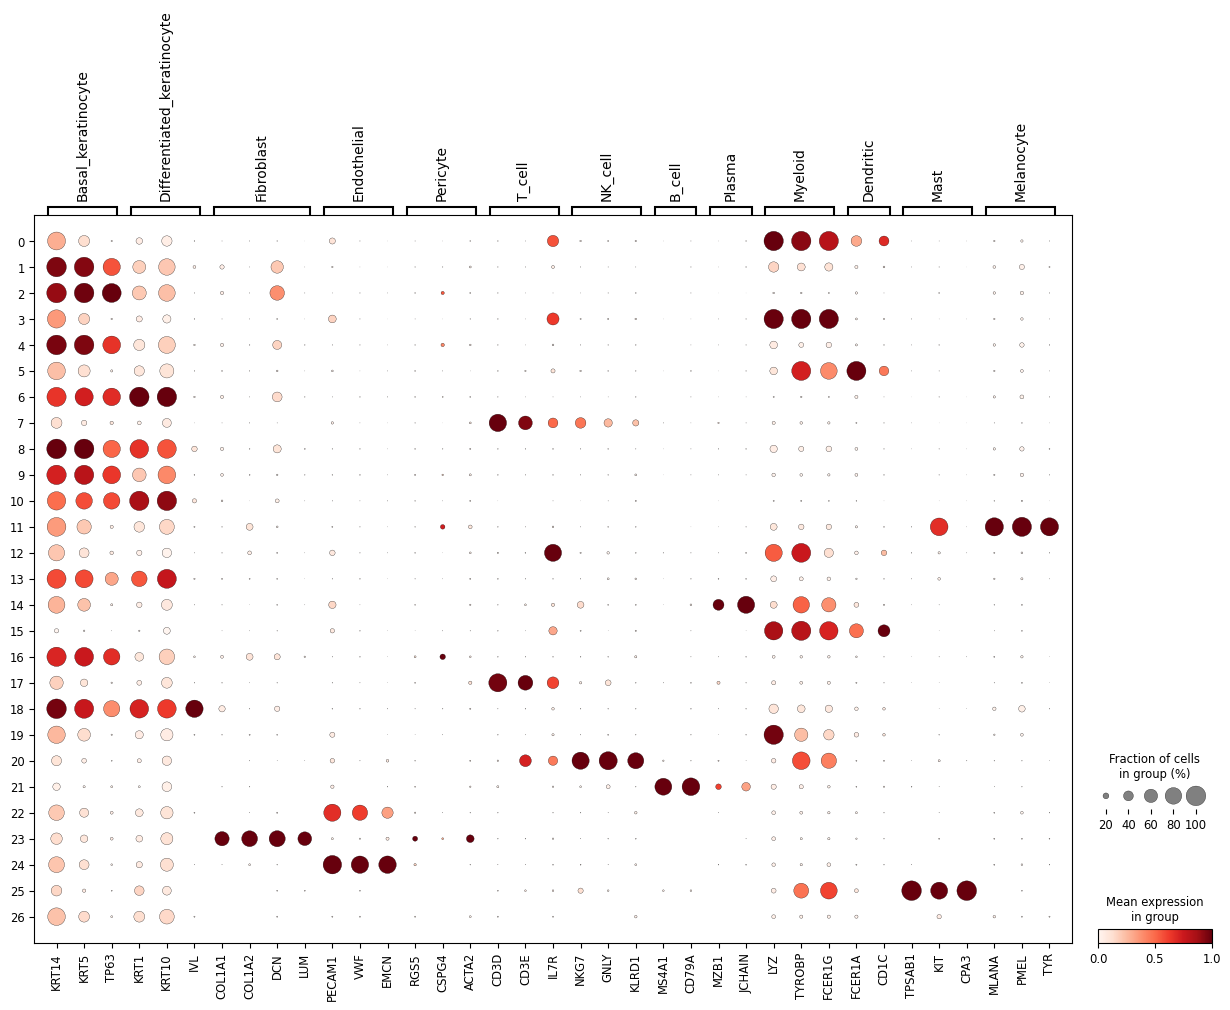

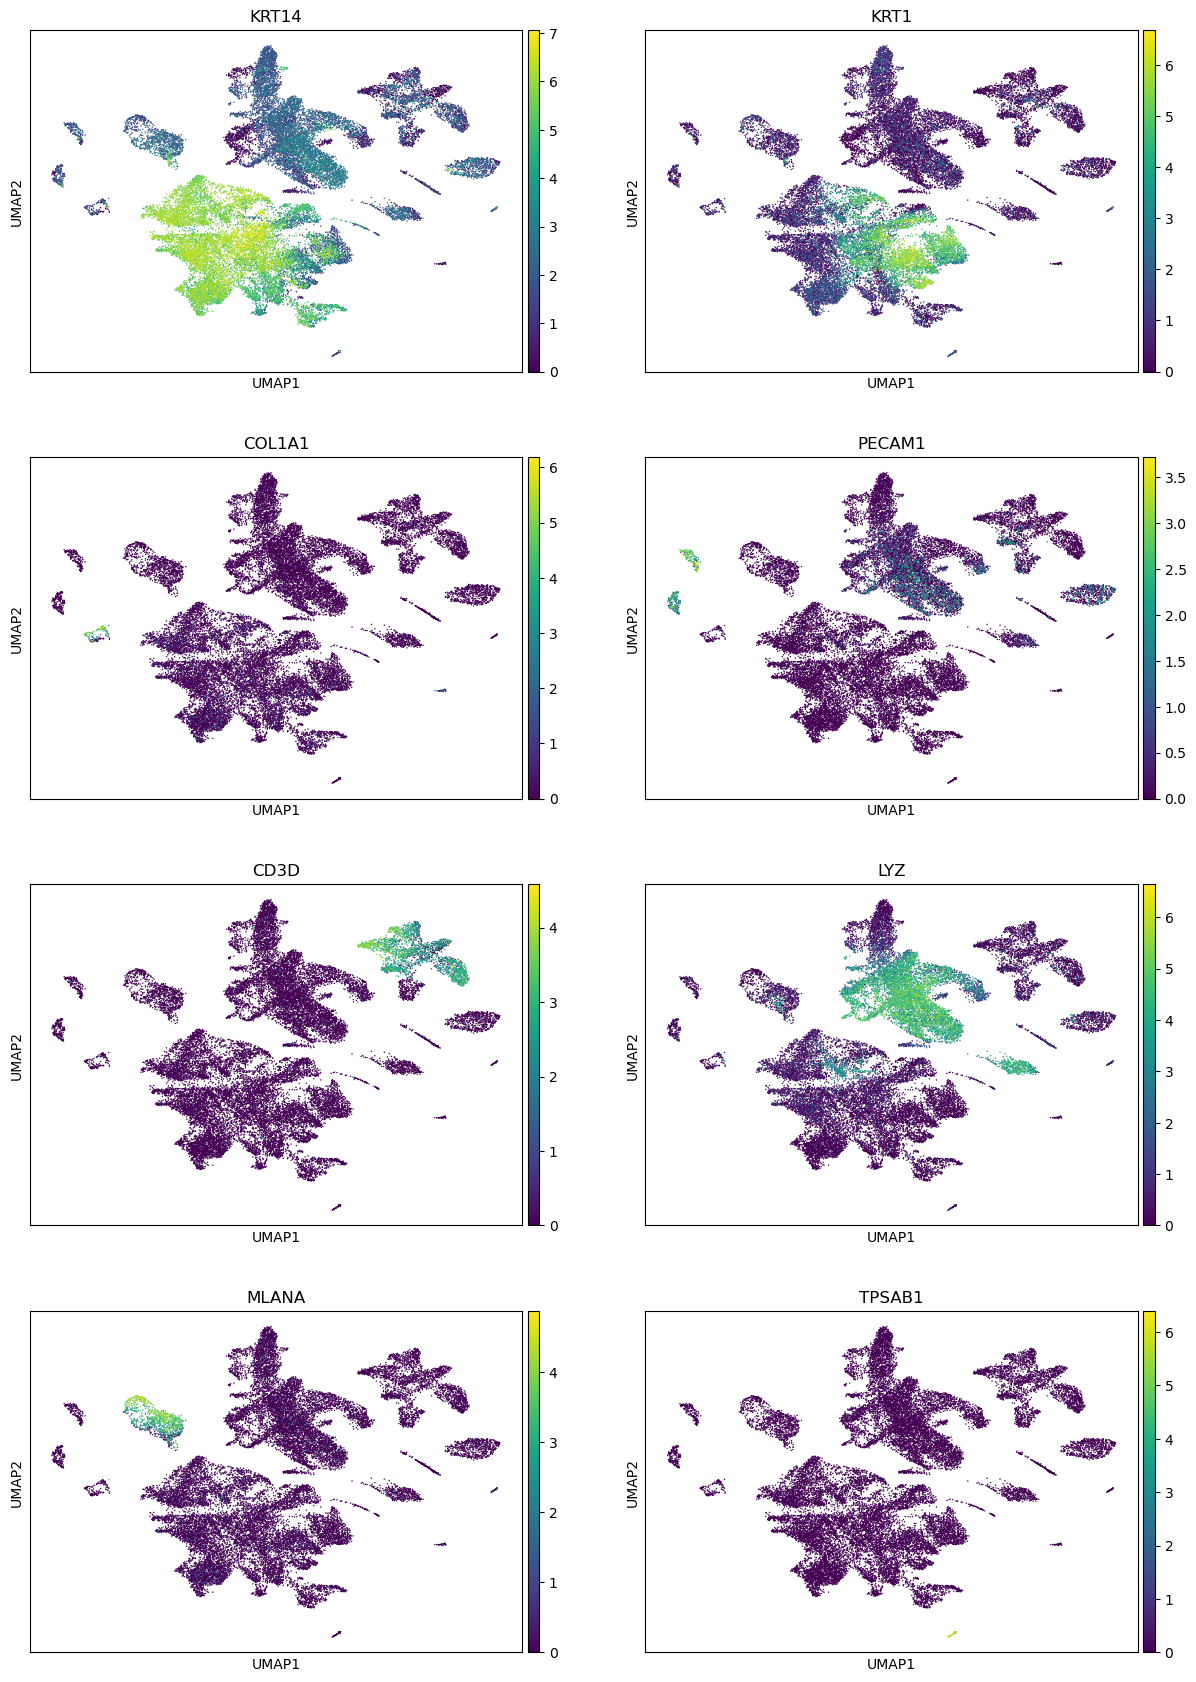

In [8]:
import scanpy as sc

cluster_key = "leiden_0.5"

if "X_umap" not in adata.obsm:
    neighbor_rep = "X_pca_harmony" if "X_pca_harmony" in adata.obsm else "X_pca"
    sc.pp.neighbors(adata, use_rep=neighbor_rep)
    sc.tl.umap(adata)

sc.pl.umap(adata, color=cluster_key, legend_loc="on data")

sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_key,
    reference="rest",
    method="wilcoxon",
    use_raw=True,
    key_added="rank_genes"
)

cluster_de_genes = {}
for cluster in adata.obs[cluster_key].cat.categories:
    df = sc.get.rank_genes_groups_df(
        adata,
        group=cluster,
        key="rank_genes",
        pval_cutoff=0.05,
        log2fc_min=0.25
    ).sort_values("logfoldchanges", ascending=False)
    
    cluster_de_genes[cluster] = df
    print("\ncluster:", cluster)
    display(df.head(10))

marker_dict = {
    "Basal_keratinocyte": ["KRT14", "KRT5", "TP63"],
    "Differentiated_keratinocyte": ["KRT1", "KRT10", "IVL"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "Endothelial": ["PECAM1", "VWF", "EMCN"],
    "Pericyte": ["RGS5", "CSPG4", "ACTA2"],
    "T_cell": ["CD3D", "CD3E", "IL7R"],
    "NK_cell": ["NKG7", "GNLY", "KLRD1"],
    "B_cell": ["MS4A1", "CD79A"],
    "Plasma": ["MZB1", "JCHAIN"],
    "Myeloid": ["LYZ", "TYROBP", "FCER1G"],
    "Dendritic": ["FCER1A", "CD1C"],
    "Mast": ["TPSAB1", "KIT", "CPA3"],
    "Melanocyte": ["MLANA", "PMEL", "TYR"]
}

available_markers = {
    cell_type: [gene for gene in genes if gene in adata.raw.var_names]
    for cell_type, genes in marker_dict.items()
}
available_markers = {cell_type: genes for cell_type, genes in available_markers.items() if genes}

sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby=cluster_key,
    use_raw=True,
    standard_scale="var"
)

feature_genes = ["KRT14", "KRT1", "COL1A1", "PECAM1", "CD3D", "LYZ", "MLANA", "TPSAB1"]
feature_genes = [gene for gene in feature_genes if gene in adata.raw.var_names]

sc.pl.umap(
    adata,
    color=feature_genes,
    use_raw=True,
    ncols=2
)


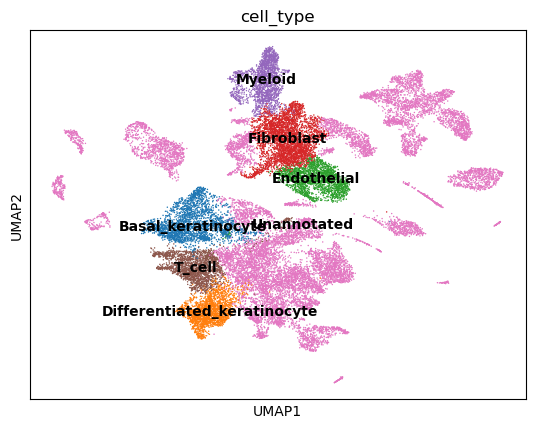

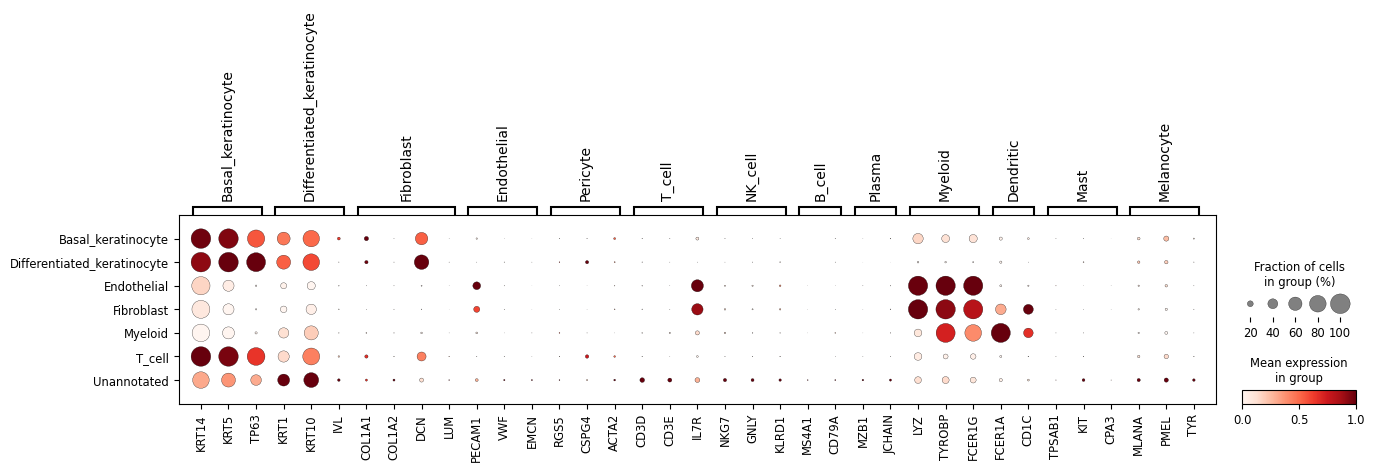

In [9]:
annotation_dict = {
    "0": "Fibroblast",
    "1": "Basal_keratinocyte",
    "2": "Differentiated_keratinocyte",
    "3": "Endothelial",
    "4": "T_cell",
    "5": "Myeloid",
}

adata.obs["cell_type"] = (
    adata.obs[cluster_key]
    .astype(str)
    .map(annotation_dict)
    .fillna("Unannotated")
    .astype("category")
)

sc.pl.umap(adata, color="cell_type", legend_loc="on data")

sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby="cell_type",
    use_raw=True,
    standard_scale="var"
)


6) Finally, compare the cell type differences between normal and cSCC and comment on how these changes can lead to cSCC development?
   a) Explore immune and non-immune cells and plot the proportion of cells in normal and cSCC. Are there any significant changes in the composition of cell types between normal and cSCC?
   b) For the immune cell population, describe T cell, B cell and myeloid cell population and their role in cSCC development
   hint : use below mrkers to identify respective cell type

In [10]:
adata.obs["cell_type"].unique()


['Unannotated', 'Differentiated_keratinocyte', 'Fibroblast', 'Myeloid', 'T_cell', 'Endothelial', 'Basal_keratinocyte']
Categories (7, object): ['Basal_keratinocyte', 'Differentiated_keratinocyte', 'Endothelial', 'Fibroblast', 'Myeloid', 'T_cell', 'Unannotated']


Cell type proportions:
condition                        cSCC    normal
cell_type                                      
Basal_keratinocyte           0.127093  0.000112
Differentiated_keratinocyte  0.011024  0.200201
Endothelial                  0.101685  0.002124
Fibroblast                   0.172502  0.019674
Myeloid                      0.047719  0.096021
T_cell                       0.094861  0.009054
Unannotated                  0.445115  0.672815


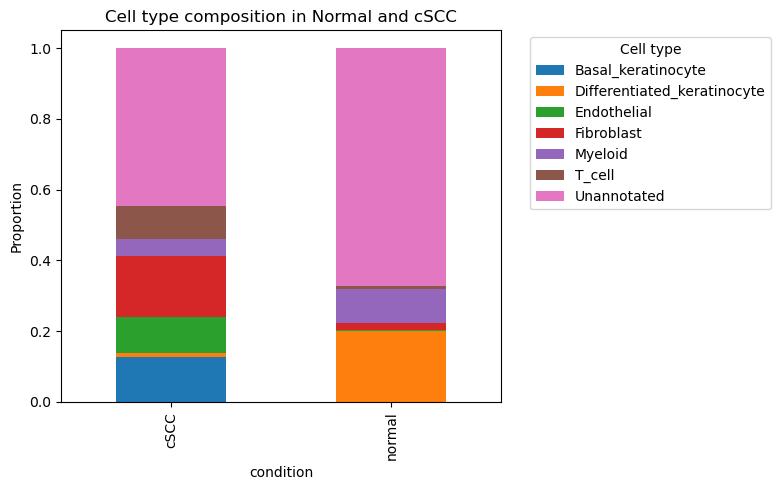


Immune cell proportions:
condition      cSCC   normal
cell_type                   
Myeloid    0.334683  0.91383
T_cell     0.665317  0.08617


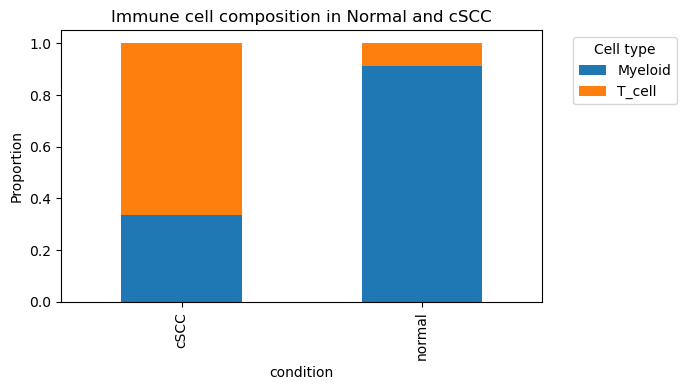

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

cell_type_counts = pd.crosstab(adata.obs["cell_type"], adata.obs["condition"])
cell_type_props = cell_type_counts.div(cell_type_counts.sum(axis=0), axis=1)
print("\nCell type proportions:")
print(cell_type_props)

ax = cell_type_props.T.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_ylabel("Proportion")
ax.set_title("Cell type composition in Normal and cSCC")
ax.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
ax.get_figure().savefig(
    FIGURE_DIR / "03_celltype_composition_normal_vs_cscc.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

immune_types = ["T_cell", "B_cell", "Plasma", "Myeloid", "Dendritic", "NK_cell"]
immune_data = adata[adata.obs["cell_type"].isin(immune_types), :].copy()
immune_counts = pd.crosstab(immune_data.obs["cell_type"], immune_data.obs["condition"])
immune_props = immune_counts.div(immune_counts.sum(axis=0), axis=1)
print("\nImmune cell proportions:")
print(immune_props)

immune_ax = immune_props.T.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4)
)
immune_ax.set_ylabel("Proportion")
immune_ax.set_title("Immune cell composition in Normal and cSCC")
immune_ax.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


(a)
The proportion of cell types differs between normal and cSCC samples. Based on the analysis, epithelial cells are relatively enriched in cSCC compared to normal samples, which is consistent with the expansion of malignant keratinocytes. In addition, fibroblasts and myeloid cells appear to be more abundant in tumor samples, suggesting remodeling of the tumor microenvironment.
In contrast, some normal cell populations are reduced or less prominent in cSCC. These changes indicate that cSCC development is not only driven by epithelial cell proliferation but also involves significant alterations in both stromal and immune cell composition.

(b)
T cells, identified by CD3E expression, play a central role in anti-tumor immunity by recognizing and eliminating malignant cells. In cSCC, T cells are present but may exhibit reduced functionality due to exhaustion or immunosuppressive signals within the tumor microenvironment.
B cells, marked by CD79A, are involved in antibody production and antigen presentation. In this dataset, B cells are present but do not show a dramatic expansion in tumor samples, suggesting a more limited or context-dependent role in cSCC.
Myeloid cells, identified by LYZ expression, are notably enriched in tumor samples. These cells, including tumor-associated macrophages, contribute to an immunosuppressive environment by inhibiting effective T cell responses and promoting tumor growth.
Overall, these findings suggest that immune dysregulation, particularly involving myeloid-driven immunosuppression and T cell dysfunction, plays an important role in cSCC development.